In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats

In [19]:
def phase_difference(x, y):
    # Calculate the analytic signal using the Hilbert transform
    analytic_x = signal.hilbert(x)
    analytic_y = signal.hilbert(y)
    
    # Calculate the instantaneous phase difference
    phase_diff = np.angle(analytic_y) - np.angle(analytic_x)
    
    # Wrap to [-pi, pi]
    return np.angle(np.exp(1j * phase_diff))


def rayleigh_stats(phase):
    # Calculate mean vector
    mean_x = np.mean(np.cos(phase))
    mean_y = np.mean(np.sin(phase))
    
    # Calculate mean resultant length and angle
    R = np.sqrt(mean_x**2 + mean_y**2)
    theta_mean = np.arctan2(mean_y, mean_x)
    
    return R, theta_mean


def plot_rayleigh(phase, R, theta_mean, save: bool = False, filepath: str = None):
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    # Plot data points (all with radius 1)
    ax.scatter(phase, np.ones_like(phase), alpha=0.5)
    
    # Plot mean vector
    ax.arrow(0, 0, theta_mean, R, alpha=0.8, width=0.02,
             edgecolor='red', facecolor='red', lw=2, zorder=5)
    
    ax.set_ylim(0, 1.1)  # Set radial limit
    ax.set_rticks([0.5, 1])  # Add some radial ticks
    ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
    ax.grid(True)
    
    ax.set_title(f"R: {R:.4f}, Mean Phase Diff (degrees): {np.degrees(theta_mean):.2f}")
    plt.tight_layout()

    if save:
        plt.savefig(f"{filepath}_rayleigh.eps", format='eps')
    
    plt.show()


def rayleigh_test(phase_diff):
    n = len(phase_diff)
    R, _ = rayleigh_stats(phase_diff)
    
    # Calculate the test statistic
    Z = n * R**2
    
    # Calculate the p-value
    p_value = np.exp(-(Z))
    
    return Z, p_value


def rayleigh_pipe(x, y, plot = False, save: bool = False, filepath: str = None):
    t = np.arange(0, x.shape[0])

    phase_diff = phase_difference(x, y)

    # Calculate Rayleigh statistics
    R, theta_mean = rayleigh_stats(phase_diff)

    # Perform Rayleigh test
    Z, p_value = rayleigh_test(phase_diff)

    # print(f"Mean resultant length (R): {R:.4f}")
    # print(f"Mean phase difference (degrees): {np.degrees(theta_mean):.2f}")

    # Calculate time shift
    # sampling_rate = 700 / 71
    # period = 1 / sampling_rate
    # time_shift = (np.abs(theta_mean)/360) * period
    # print(f"Mean phase difference (milliseconds): {time_shift * 1e3:.2f}")

    if plot:
        # Plot the results
        plot_rayleigh(phase_diff, R, theta_mean, save, filepath)

        # Plot the original time series
        plt.figure(figsize=(10, 6))
        plt.plot(t, x, label='Terminal')
        plt.plot(t, y, label='Nac Cluster')
        plt.axvline(x=100, color='r', linestyle='--')

        ax = plt.gca()
        def format_func(value, tick_number):
            return int(value/10) - 10

        ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))

        plt.xlabel('Time (in s)')
        plt.ylabel('Amplitude')
        plt.title('Original Time Series')
        plt.legend()
        plt.savefig(f"{filepath}_timeseries.eps", format='eps')
        plt.show()

        # plt.hist(phase_diff, bins=36, range=(-np.pi, np.pi))
        # plt.title("Phase Difference Histogram")
        # plt.xlabel("Phase Difference (radians)")
        # plt.ylabel("Count")
        # plt.show()
        
    return R, np.degrees(theta_mean), Z, p_value

In [4]:
source = "/Users/hades/Desktop/Bruchas Lab/Encoder_Decoder/DJM_binary_classification/Relate_Terminal_to_NAc/signal_data"
files = sorted([f for f in os.listdir(source) if f.endswith(".npy")])
full_paths = [os.path.join(source, f) for f in files]
np_arrs = [np.load(f) for f in full_paths]

nac1 = np_arrs[1]
nac2 = np_arrs[2]
nac3 = np_arrs[3]
nac4 = np_arrs[4]
nac5 = np_arrs[5]

ecb = np_arrs[0]
terminal = np_arrs[6]

clusters = [
    nac1,
    nac2,
    nac3,
    nac4,
    nac5
]

sampling_rate = 700/71

In [ ]:
"""
Get mean phase diff R value for each trace in cluster
"""

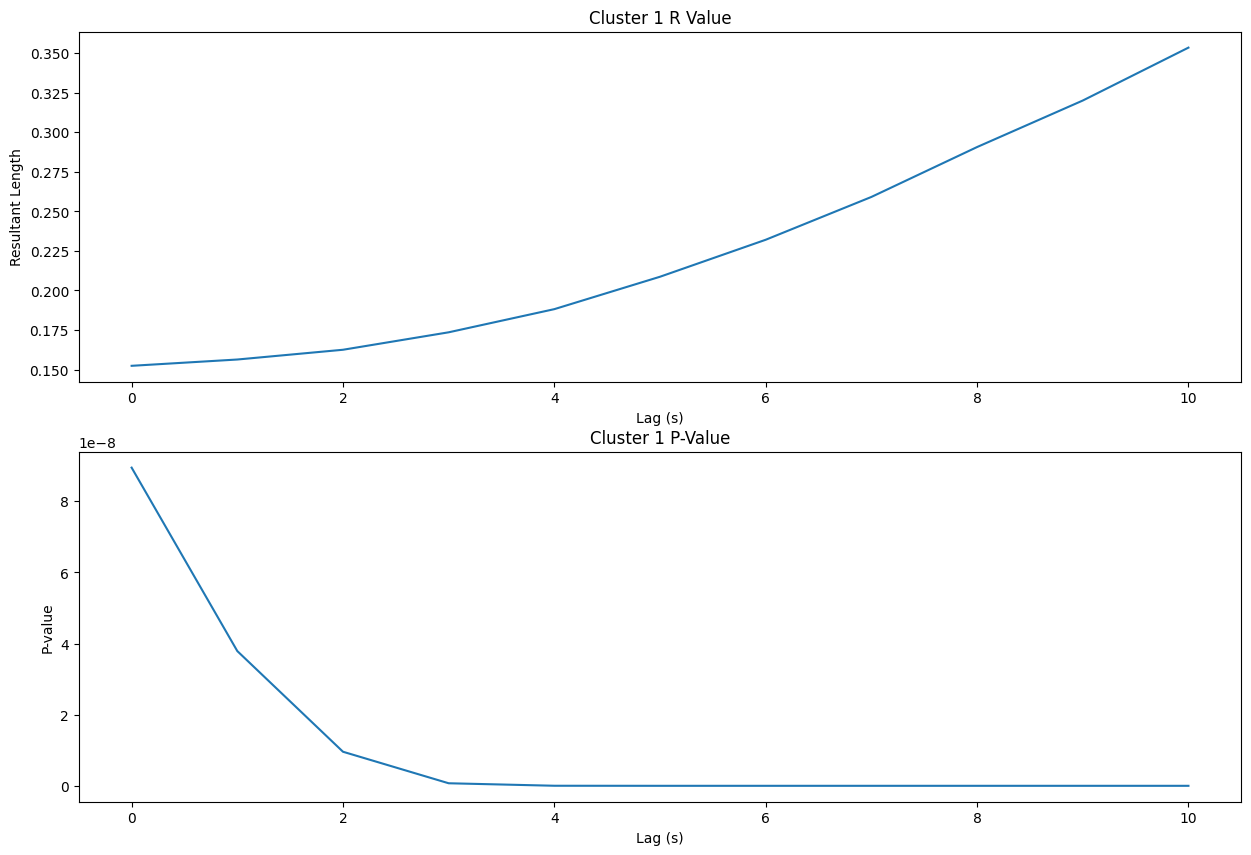

<Figure size 640x480 with 0 Axes>

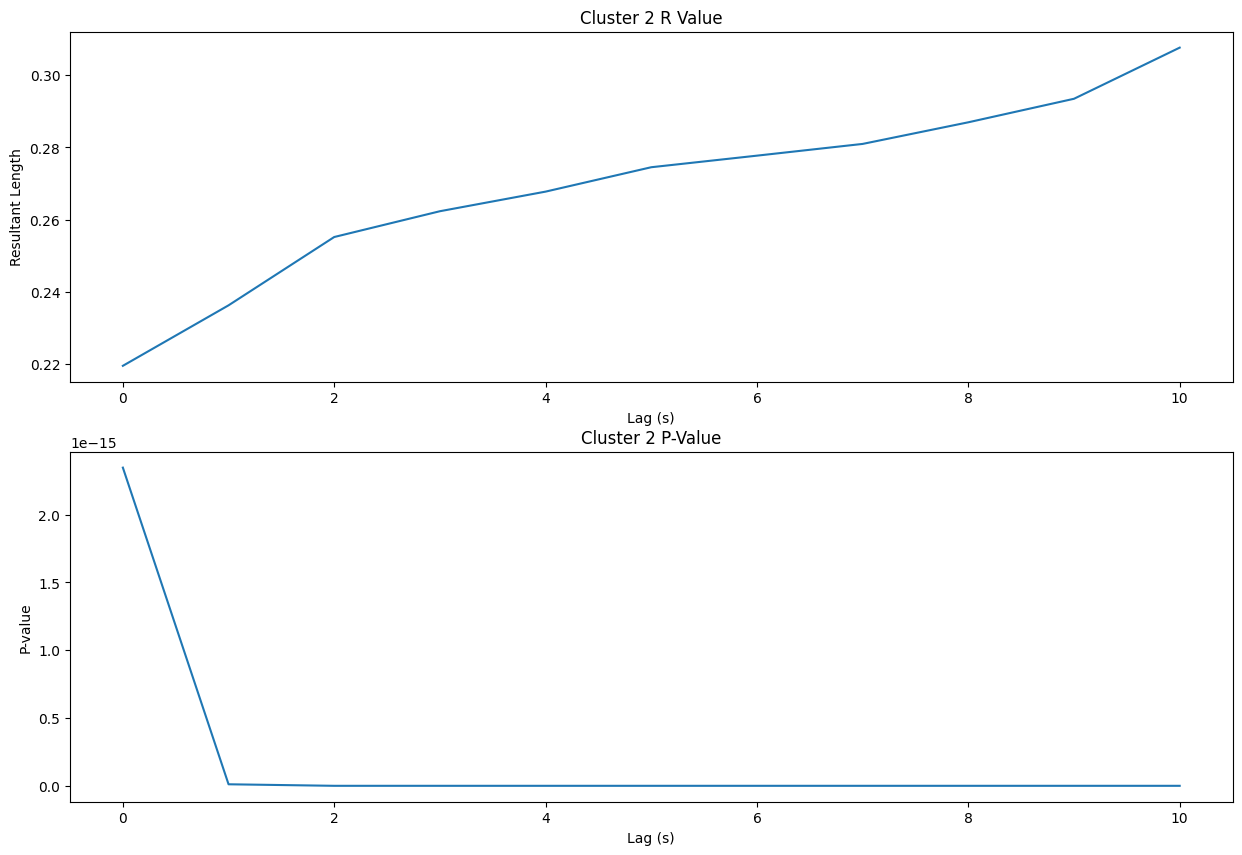

<Figure size 640x480 with 0 Axes>

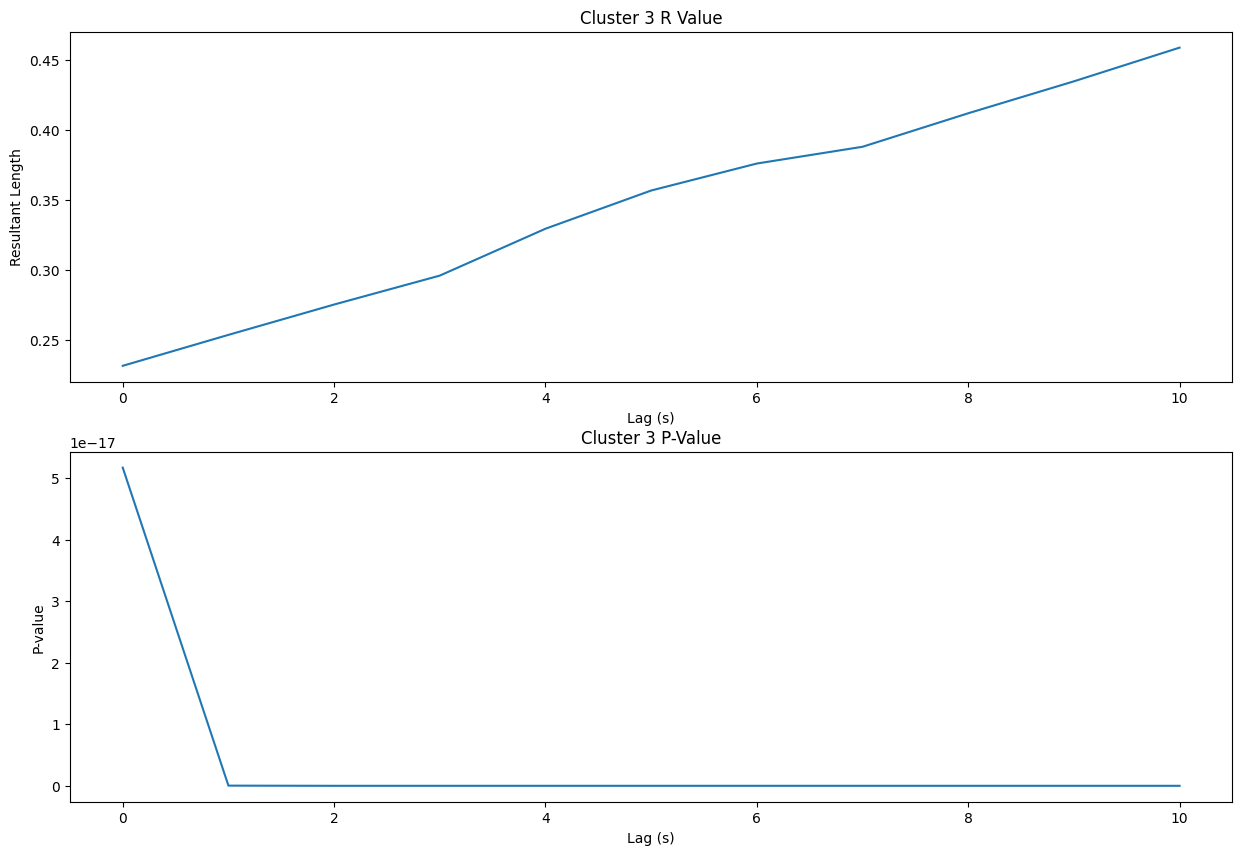

<Figure size 640x480 with 0 Axes>

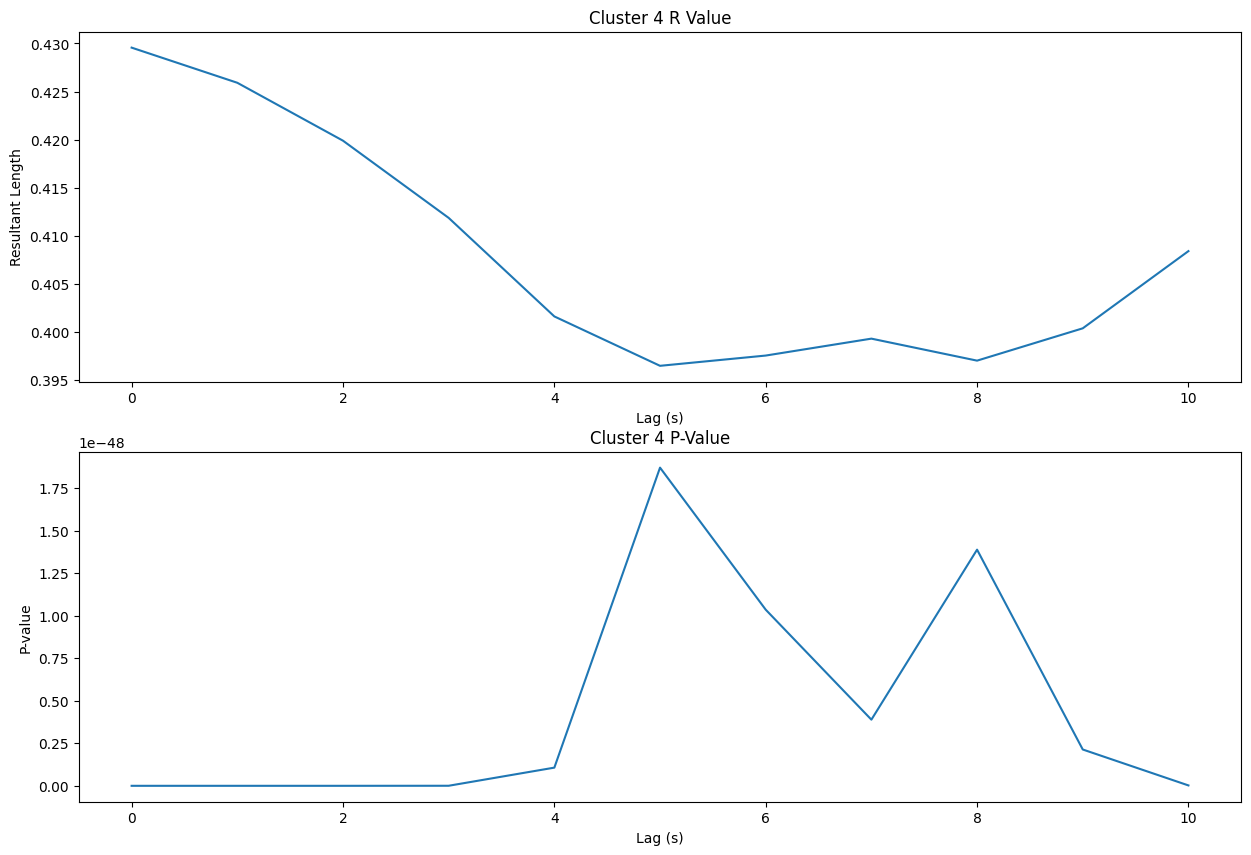

<Figure size 640x480 with 0 Axes>

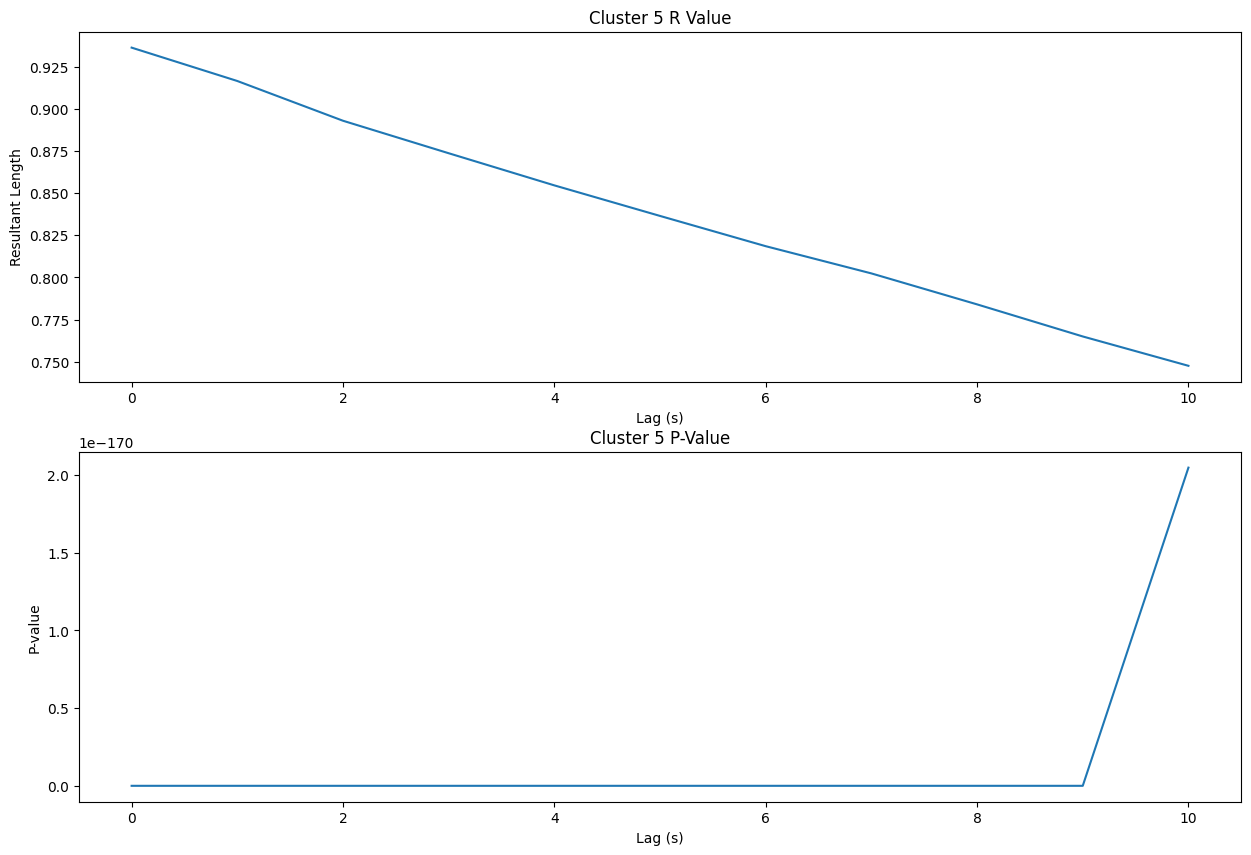

<Figure size 640x480 with 0 Axes>

In [15]:
delay_range = 10

for i, cluster in enumerate(clusters, start=1):
    all_res = np.ndarray((delay_range + 1, 4))
    
    reg_res = rayleigh_pipe(terminal, cluster, plot=False)
    all_res[0, 0] = reg_res[0]
    all_res[0, 1] = reg_res[1]
    all_res[0, 2] = reg_res[2]
    all_res[0, 3] = reg_res[3]
    # print(f"Cluster {i} Z: {reg_res[2]}")
    # print(f"Cluster {i} P: {reg_res[3]}")

    for j in range(1, delay_range + 1):
        delayed_cluster = np.roll(cluster, j * 10)
        delayed_rayleigh = rayleigh_pipe(terminal, delayed_cluster, plot=False)
        all_res[j, 0] = delayed_rayleigh[0]
        all_res[j, 1] = delayed_rayleigh[1]
        all_res[j, 2] = delayed_rayleigh[2]
        all_res[j, 3] = delayed_rayleigh[3]
    
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 1, 1)
    plt.plot(all_res[:, 0])
    plt.title(f'Cluster {i} R Value')
    plt.xlabel('Lag (s)')
    plt.ylabel('Resultant Length')

    # plt.subplot(4, 1, 2)
    # plt.plot(all_res[:, 1])
    # plt.title(f'Cluster {i} Mean Phase Shift')
    # plt.xlabel('Lag (s)')
    # plt.ylabel('Phase Angle (degree)')

    # plt.subplot(4, 1, 3)
    # plt.plot(all_res[:, 2])
    # plt.title(f'Cluster {i} Rayleigh Test Statistic')
    # plt.xlabel('Lag (s)')
    # plt.ylabel('Z')

    plt.subplot(2, 1, 2)
    plt.plot(all_res[:, 3])
    plt.title(f'Cluster {i} P-Value')
    plt.xlabel('Lag (s)')
    plt.ylabel('P-value')

    plt.show()
    plt.savefig(f"Shifted_Cluster{i}_R_Phase.png")